House Price Dataset
    Area_sqft  Bedrooms  Bathrooms  House_Age  Price_Lakh
0         800         2          1         20          25
1         900         2          1         18          28
2        1000         2          2         15          32
3        1100         2          2         14          35
4        1200         3          2         12          40
5        1300         3          2         10          44
6        1400         3          2          9          48
7        1500         3          2          8          52
8        1600         3          2          7          56
9        1700         3          3          6          61
10       1800         3          3          5          65
11       1900         3          3          5          70
12       2000         4          3          4          76
13       2200         4          3          4          84
14       2400         4          3          3          92
15       2500         4          3          3       

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


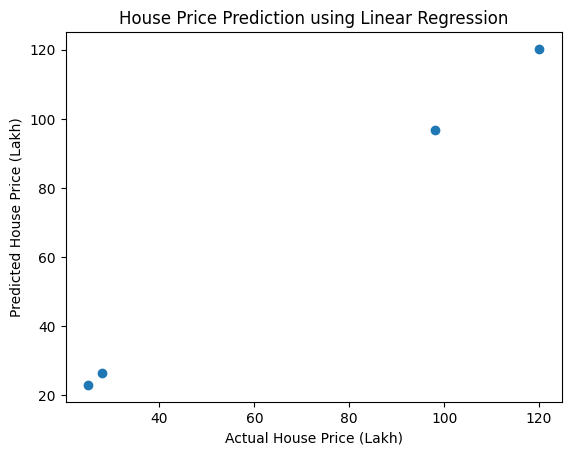

In [ ]:
# House Price Prediction using Linear Regression
# Aim: Predict house prices using an appropriate
#      machine learning algorithm.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# STEP 1: Create a basic house price dataset
# ---------------------------------------------------------

data = {
    'Area_sqft': [
        800, 900, 1000, 1100, 1200,
        1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2200, 2400,
        2500, 2700, 3000, 3200, 3500
    ],

    'Bedrooms': [
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4,
        4, 4, 4, 5, 5
    ],

    'Bathrooms': [
        1, 1, 2, 2, 2,
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 4, 4, 4, 5
    ],

    'House_Age': [
        20, 18, 15, 14, 12,
        10, 9, 8, 7, 6,
        5, 5, 4, 4, 3,
        3, 2, 2, 1, 1
    ],

    'Price_Lakh': [
        25, 28, 32, 35, 40,
        44, 48, 52, 56, 61,
        65, 70, 76, 84, 92,
        98, 108, 120, 130, 145
    ]
}

df = pd.DataFrame(data)

print("House Price Dataset")
print("=" * 50)
print(df)


# ---------------------------------------------------------
# STEP 2: Select input features and target
# ---------------------------------------------------------

X = df[
    ['Area_sqft', 'Bedrooms', 'Bathrooms', 'House_Age']
]

y = df['Price_Lakh']


# ---------------------------------------------------------
# STEP 3: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 4: Create Linear Regression model
# ---------------------------------------------------------

model = LinearRegression()


# ---------------------------------------------------------
# STEP 5: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 6: Predict test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 7: Display actual vs predicted prices
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("HOUSE PRICE PREDICTION RESULTS")
print("=" * 50)

print("\nActual vs Predicted Price:")

for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual: ₹",
        round(actual, 2),
        "Lakh\tPredicted: ₹",
        round(predicted, 2),
        "Lakh"
    )


# ---------------------------------------------------------
# STEP 8: Calculate model performance
# ---------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error (MSE):",
      round(mse, 4))

print("R² Score:",
      round(r2, 4))


# ---------------------------------------------------------
# STEP 9: Display model coefficients
# ---------------------------------------------------------

print("\nModel Coefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(
        feature,
        ":",
        round(coefficient, 4)
    )

print("\nIntercept:",
      round(model.intercept_, 4))


# ---------------------------------------------------------
# STEP 10: Predict price of a new house
# ---------------------------------------------------------

new_house = np.array([
    [1800, 3, 3, 5]
])

predicted_price = model.predict(new_house)

print("\n" + "=" * 50)
print("NEW HOUSE PRICE PREDICTION")
print("=" * 50)

print("\nHouse Details:")
print("Area: 1800 sq.ft")
print("Bedrooms: 3")
print("Bathrooms: 3")
print("House Age: 5 years")

print(
    "\nPredicted House Price: ₹",
    round(predicted_price[0], 2),
    "Lakh"
)


# ---------------------------------------------------------
# STEP 11: Plot Actual vs Predicted Prices
# ---------------------------------------------------------

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual House Price (Lakh)")
plt.ylabel("Predicted House Price (Lakh)")
plt.title("House Price Prediction using Linear Regression")

plt.show()